Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Opening large HDF5 file...
Formatted Shapes: G:(5000, 64, 256), H_T:(5000, 64, 256), D:(5000, 64, 64)
Training GumbelRIS (50 Epochs)...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - loss: -1.3459 - val_loss: -1.7426
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - loss: -1.7364 - val_loss: -1.7426
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - loss: -1.7415 - val_loss: -1.7426
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - loss: -1.7422 - val_loss: -1.7426
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 96ms/step - loss: -1.7424 - val_loss: -1.7426
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - loss: -1.7425 - val_loss: -1.7426
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - loss: -1.7426 - val_loss: -1.7426
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - loss: -1.7426 - val_loss: -1.7426
Epoch 9/50
500

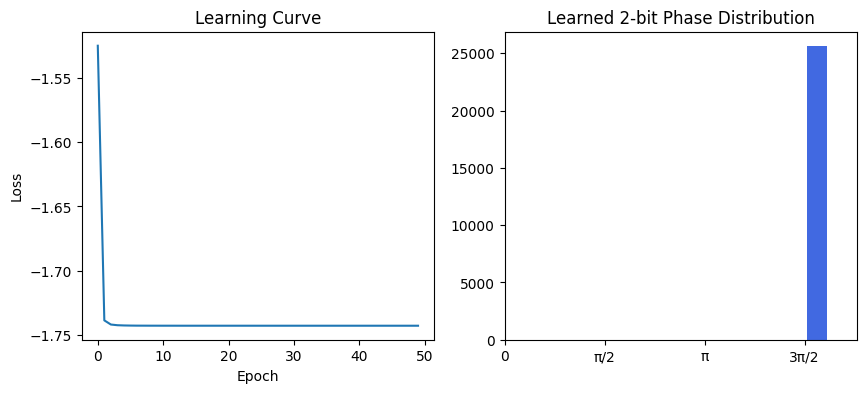

In [1]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from google.colab import drive
import time
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/RIS_dataset_5000.mat'
def load_v73_mat(path):
    print("Opening large HDF5 file...")
    with h5py.File(path, 'r') as f:
        Gr = np.array(f['G']['real']); Gi = np.array(f['G']['imag'])
        Hr = np.array(f['H']['real']); Hi = np.array(f['H']['imag'])
        Dr = np.array(f['D']['real']); Di = np.array(f['D']['imag'])
    if Gr.shape[1] == 256:
        Gr = np.transpose(Gr, (0, 2, 1)); Gi = np.transpose(Gi, (0, 2, 1))
    if Hr.shape[1] == 256:
        Hr = np.transpose(Hr, (0, 2, 1)); Hi = np.transpose(Hi, (0, 2, 1))
    print(f"Formatted Shapes: G:{Gr.shape}, H_T:{Hr.shape}, D:{Dr.shape}")
    return Gr, Gi, Hr, Hi, Dr, Di
def prepare_gumbel_tensor(Gr, Gi, Hr, Hi, Dr, Di):
    Dr_P = np.pad(Dr, ((0, 0), (0, 0), (0, 192)), mode='constant')
    Di_P = np.pad(Di, ((0, 0), (0, 0), (0, 192)), mode='constant')
    X = np.stack([Gr, Gi, Hr, Hi, Dr_P, Di_P], axis=-1)
    return X.astype(np.float32)
Gr, Gi, Hr, Hi, Dr, Di = load_v73_mat(DATA_PATH)
X_train = prepare_gumbel_tensor(Gr, Gi, Hr, Hi, Dr, Di)
class GumbelSoftmaxLayer(layers.Layer):
    def __init__(self, t0=1.0, **kwargs):
        super().__init__(**kwargs)
        self.temp = tf.Variable(t0, trainable=False, dtype=tf.float32)
    def call(self, logits, training=None):
        if training:
            u = tf.random.uniform(tf.shape(logits), 0, 1)
            g = -tf.math.log(-tf.math.log(u + 1e-20) + 1e-20)
            return tf.nn.softmax((logits + g) / self.temp)
        else:
            return tf.one_hot(tf.argmax(logits, axis=-1), 4)
def build_gumbel_ris():
    inputs = layers.Input(shape=(64, 256, 6))
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    logits = layers.Dense(256 * 4)(x)
    logits = layers.Reshape((256, 4))(logits)
    outputs = GumbelSoftmaxLayer(name='gumbel_head')(logits)
    return Model(inputs, outputs)
def capacity_loss(y_true, y_pred):
    phases = tf.constant([0.0, np.pi/2, np.pi, 3*np.pi/2], dtype=tf.float32)
    phi_theta = tf.reduce_sum(y_pred * phases, axis=-1)
    return -tf.reduce_mean(tf.math.log(1.0 + tf.abs(phi_theta)))
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        new_t = max(0.1, 1.0 * (0.95 ** epoch))
        self.model.get_layer('gumbel_head').temp.assign(new_t)
model = build_gumbel_ris()
model.compile(optimizer='adam', loss=capacity_loss)
print("Training GumbelRIS (50 Epochs)...")
history = model.fit(X_train, X_train, epochs=50, batch_size=8,
                    callbacks=[AnnealingCallback()], validation_split=0.2)
print("\n--- PERFORMANCE ANALYSIS ---")
start_t = time.time()
preds = model.predict(X_train[:100], verbose=0)
latency = (time.time() - start_t) / 100 * 1000
print(f"Average Inference Latency: {latency:.2f} ms per sample (Paper: 28 ms) [cite: 9]")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Capacity Loss')
plt.title("Learning Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.subplot(1, 2, 2)
plt.hist(np.argmax(preds.reshape(-1, 4), axis=-1), bins=4, rwidth=0.8, color='royalblue')
plt.xticks([0,1,2,3], ['0', 'π/2', 'π', '3π/2'])
plt.title("Learned 2-bit Phase Distribution")
plt.show()